# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [14]:
# 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# 2
df = pd.read_csv('cleaned_airbnb_data_6.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (10480, 77)
Columns: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'calenda

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_cleaned
0,27886,https://www.airbnb.com/rooms/27886,20250911031321,2025-09-11,city scrape,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,...,4.93,4.90,4.78,f,1,0,1,0,1.87,132.0
1,28871,https://www.airbnb.com/rooms/28871,20250911031321,2025-09-11,city scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,...,4.94,4.93,4.83,f,2,0,2,0,3.99,89.0
2,29051,https://www.airbnb.com/rooms/29051,20250911031321,2025-09-11,city scrape,Comfortable single / double room,This room can also be rented as a single or a ...,the street is quite lively especially on weeke...,https://a0.muscache.com/pictures/162009/bd6be2...,124245,...,4.92,4.87,4.79,f,2,0,2,0,4.81,61.0
3,44391,https://www.airbnb.com/rooms/44391,20250911031321,2025-09-11,previous scrape,Quiet 2-bedroom Amsterdam city centre apartment,Guests greatly appreciate the unique location ...,The appartment is located in the city centre. ...,https://a0.muscache.com/pictures/97741545/3900...,194779,...,4.90,4.68,4.50,f,1,1,0,0,0.23,NaN
4,48373,https://www.airbnb.com/rooms/48373,20250911031321,2025-09-11,previous scrape,Cozy family home in Amsterdam South,Charming modern apartment in the quiet and gre...,Apartment is located between Amsterdamse Bos a...,https://a0.muscache.com/pictures/miso/Hosting-...,220434,...,5.00,4.60,5.00,f,1,1,0,0,0.19,NaN


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



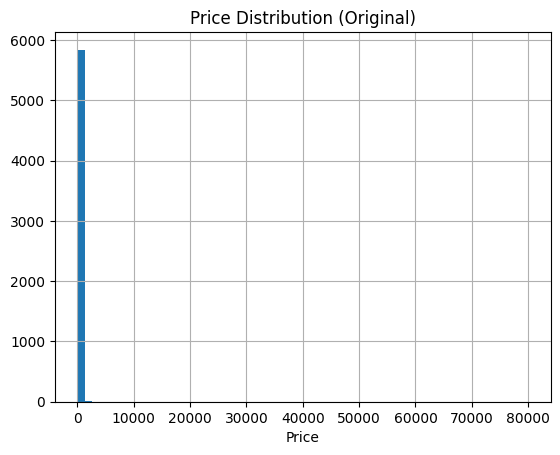

In [16]:
# 1
df['price_cleaned'].hist(bins=60)
plt.title('Price Distribution (Original)')
plt.xlabel('Price')
plt.show()

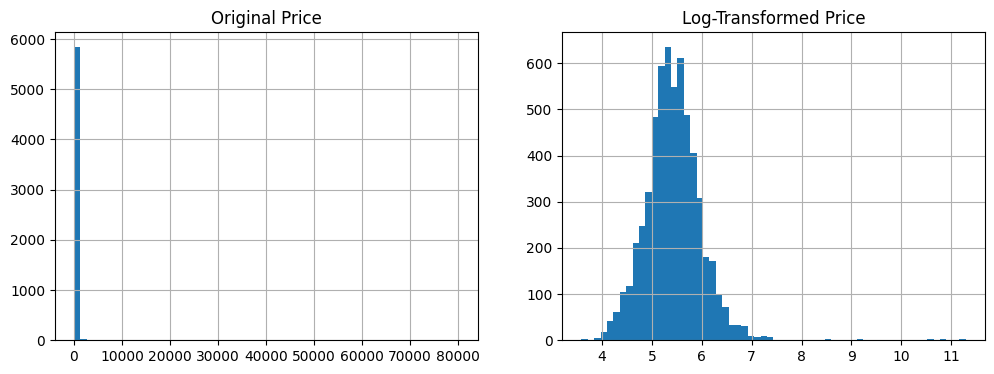

Original skewness: 31.55
Transformed skewness: 1.47


In [17]:
# 2
df['log_price'] = np.log1p(df['price_cleaned'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['price_cleaned'].hist(bins=60, ax=axes[0])
axes[0].set_title('Original Price')
df['log_price'].hist(bins=60, ax=axes[1])
axes[1].set_title('Log-Transformed Price')
plt.show()

print(f'Original skewness: {df["price_cleaned"].skew():.2f}')
print(f'Transformed skewness: {df["log_price"].skew():.2f}')

### ✍️ Your Response: 🔧
1. I examined price_cleaned, the nightly listing price in USD. As shown in the left histogram, the data is heavily right-skewed. Nearly all listings pile up near zero while a handful of outliers stretch the x-axis out to $80,000, making the distribution nearly impossible to read.

2. I applied a log transformation using np.log1p(), which computes log(price + 1). Log transformation is the standard choice for skewed financial data because it compresses extreme high values without distorting the relative differences between listings.

3. The right histogram shows the result. The distribution is now roughly bell-shaped and centered around a log-price of 5, with the spread clearly visible. This makes it far easier for a stakeholder to see where most listings are priced, and it makes the column much better behaved as an input to any pricing model or statistical analysis.

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [18]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max scale
scaler = MinMaxScaler()
df['price_minmax'] = scaler.fit_transform(df[['price_cleaned']])

# Z-score scale
scaler2 = StandardScaler()
df['minimum_nights_zscore'] = scaler2.fit_transform(df[['minimum_nights']])

# Preview
df[['price_cleaned', 'price_minmax', 'minimum_nights', 'minimum_nights_zscore']].head(10)


,price_cleaned,price_minmax,minimum_nights,minimum_nights_zscore
0,132.0,0.001213,3,-0.070193
1,89.0,0.000675,2,-0.120682
2,61.0,0.000325,2,-0.120682
3,NaN,NaN,3,-0.070193
4,NaN,NaN,3,-0.070193
5,322.0,0.003588,3,-0.070193
6,457.0,0.005276,2,-0.120682
7,198.0,0.002038,7,0.131762
8,162.0,0.001588,2,-0.120682
9,NaN,NaN,1,-0.171170


### ✍️ Your Response: 🔧
1. I scaled price_cleaned using Min-Max scaling and minimum_nights using Z-score normalization. The results are visible in the table.  price_minmax compresses prices like 132 and 457 down to values like 0.0012 and 0.0053.

2. These scaled values are most useful when combining both columns into a model or composite score. The original price_cleaned ranges into the thousands while minimum_nights typically sits between 1 and 30, so any model using raw values would be dominated by price alone. Scaling puts them on equal footing so both features contribute fairly.

3. A data scientist building a search ranking or recommendation model would benefit most, since algorithms like k-means clustering or linear regression require features on a comparable scale to produce reliable results. A product manager designing a "value score" for listings could also use the Min-Max price column to rank affordability on a clean 0-1 index that's easy to display to guests.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [19]:
# 1
df['review_volume'] = pd.cut(df['number_of_reviews'],
                              bins=[0, 10, 50, df['number_of_reviews'].max()],
                              labels=['Low', 'Medium', 'High'],
                              include_lowest=True)

print(df['review_volume'].value_counts())

review_volume
Low       5417
Medium    3200
High      1863
Name: count, dtype: int64


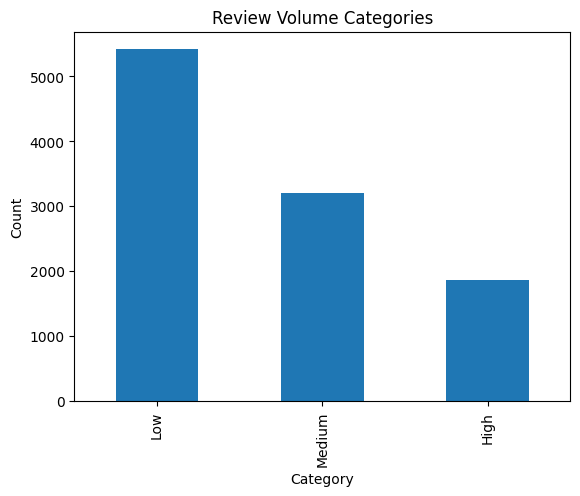

In [20]:
# 2
df['review_volume'].value_counts().plot(kind='bar')
plt.title('Review Volume Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

### ✍️ Your Response: 🔧
1. I grouped number_of_reviews into 3 categories:  Low (0–10), Medium (11–50), and High (50+).

2. A marketing team doesn't need to know a listing has exactly 47 reviews. They just need to know it's a "Medium" activity listing so they can segment and target it appropriately without getting lost in the noise of raw counts.

3. A marketing manager could use these segments to tailor campaigns. For example, nudging "Low" volume hosts to encourage guests to leave reviews, or highlighting "High" volume listings in search results as trusted, well-reviewed options for guests.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

In [21]:
# 1
df['price_per_guest'] = (df['price_cleaned'] / df['accommodates']).round(2)

In [22]:
# 2
df['is_long_term'] = (df['minimum_nights'] >= 30).astype(int)

In [23]:
# 3
df[['price_cleaned', 'accommodates', 'price_per_guest', 'minimum_nights', 'is_long_term']].head(10)

,price_cleaned,accommodates,price_per_guest,minimum_nights,is_long_term
0,132.0,2,66.00,3,0
1,89.0,2,44.50,2,0
2,61.0,2,30.50,2,0
3,NaN,4,NaN,3,0
4,NaN,4,NaN,3,0
5,322.0,3,107.33,3,0
6,457.0,4,114.25,2,0
7,198.0,5,39.60,7,0
8,162.0,2,81.00,2,0
9,NaN,3,NaN,1,0


### ✍️ Your Response: 🔧 🔧
1. I created price_per_guest, which divides the nightly price by the number of guests the listing accommodates, and is_long_term, a binary flag that marks listings requiring a minimum stay of 30 nights or more.

2. A guest or travel planner would use price_per_guest to compare true cost across listings of different sizes, while a city housing analyst or Airbnb policy team would use is_long_term to identify listings that function more like rentals than short-term stays.

3. price_per_guest prevents groups from overpaying by making per-person cost transparent across listings of different sizes. is_long_term helps the platform flag listings that may be subject to local housing regulations around long-term rentals, supporting smarter compliance decisions.



## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [24]:
# 1
room_dummies = pd.get_dummies(df['room_type'], prefix='room')
df = pd.concat([df, room_dummies], axis=1)

print(df[['room_type'] + list(room_dummies.columns)].head(10))

         room_type  room_Entire home/apt  room_Hotel room  room_Private room  \
0     Private room                 False            False               True   
1     Private room                 False            False               True   
2     Private room                 False            False               True   
3  Entire home/apt                  True            False              False   
4  Entire home/apt                  True            False              False   
5  Entire home/apt                  True            False              False   
6  Entire home/apt                  True            False              False   
7  Entire home/apt                  True            False              False   
8  Entire home/apt                  True            False              False   
9  Entire home/apt                  True            False              False   

   room_Shared room  
0             False  
1             False  
2             False  
3             False  
4        

### ✍️ Your Response: 🔧
1. I encoded room_type because it's a nominal categorical column with no natural order. Entire home, Private room, Shared room, and Hotel room are just different types, not rankings.
2. I used one-hot encoding, which creates a separate binary column for each room type so no false ranking is implied between categories.
3. A pricing model can now use these binary columns as inputs to learn that, for example, Entire homes tend to command higher prices than Shared rooms. A dashboard could also use these flags to quickly filter and compare performance across room types.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [25]:
cols_to_drop = ['listing_url', 'scrape_id', 'picture_url', 'host_url',
                'host_thumbnail_url', 'host_picture_url', 'description',
                'neighborhood_overview', 'host_verifications']

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(df.dtypes)
print(f'Shape: {df.shape}')

id                       int64
last_scraped            object
source                  object
name                    object
host_id                  int64
                         ...  
is_long_term             int64
room_Entire home/apt      bool
room_Hotel room           bool
room_Private room         bool
room_Shared room          bool
Length: 78, dtype: object
Shape: (10480, 78)


In [26]:
# export csv here 🔧
df.to_csv('cleaned_airbnb_data_7.csv', index=False)
print('File saved')

File saved


## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. The log transformation on price felt the most important because the original distribution was so skewed it was almost unreadable. A single step made the data actually usable for analysis. It was interesting to see how one line of code could so dramatically change what the data communicates visually.

2. price_per_guest would be most immediately useful to a host because it reframes their pricing in terms guests actually care about making it easier to competitively position a listing against others of different sizes. A city planner would benefit most from is_long_term, since it flags listings that may be functioning as de facto rentals rather than short-term stays, which has direct implications for housing policy.

3. The next step would be building a pricing recommendation dashboard that uses price_per_guest, review_volume, and the encoded room_type columns to show hosts how their listing compares to similar properties in their neighborhood. Adding a predicted "optimal price" column using a regression model.

4. In athletic marketing and nonprofit stewardship, segmenting your audience is just as critical as it is in Airbnb analytics. The review_volume binning mirrors how a marketing team might segment donors into Low, Medium, and High engagement tiers to tailor outreach. The feature engineering steps also reflect how nonprofits and athletic programs build composite metrics, like cost-per-impression or revenue-per-event, to make smarter decisions with limited budgets.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [27]:
!jupyter nbconvert --to html "assignment_07_data_transformation_MonbergTobin.ipynb"

[NbConvertApp] Converting notebook assignment_07_data_transformation_MonbergTobin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 425185 bytes to assignment_07_data_transformation_MonbergTobin.html
